# 전기 화물차 장거리 운송 에너지 예측 및 최적 충전 계획

**고정 차량:** Volvo FH Electric  
**고정 경로:** 부산신항 → 인천국제공항 화물터미널

TMAP 화물차 경로를 작은 구간으로 나누고, 구간별 에너지와 SOC를 계산해 충전 계획을 추천한다.

## 전체 처리 흐름

사용자 입력 → 고정 경로 → 최대 10km Segment → ML 예측 → SOC 계산 → 휴게소 연결 → 충전 계획 추천


## 0. 환경과 공통 설정

In [73]:
# Windows와 WSL에서 동일하게 동작하도록 상대경로와 pathlib를 사용한다.
import os
import json
import itertools
from datetime import datetime, timedelta
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import geopandas as gpd

from dotenv import load_dotenv
from shapely.geometry import LineString, Point
from shapely.ops import substring
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'datas_ml'
PROJECT_DATA_DIR = BASE_DIR / 'project_data'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(BASE_DIR / '.env')
TMAP_APP_KEY = os.getenv('TMAP_APP_KEY')
DATA_GO_KR_SERVICE_KEY = os.getenv('DATA_GO_KR_SERVICE_KEY')

target = 'energy_consumption_kwhper100km'
VOLVO_REFERENCE_KWH_100KM = 110.0
VOLVO_USABLE_BATTERY_KWH = 460.0
VOLVO_MAX_CHARGING_KW = 350.0
MAX_SEGMENT_KM = 10.0
# 서비스 예측에 사용할 고정 입력값이다.
SIMULATED_ROAD_GRADE_PCT = 1.5

sns.set_theme(style='whitegrid')
plt.rcParams['axes.unicode_minus'] = False

Volvo 설정값: 사용 가능 배터리 460kWh, 최대 충전 출력 350kW, 기준 소비량 110kWh/100km

In [74]:
# 외부 API 키와 필수 파일 준비 상태를 먼저 확인한다. 키 값 자체는 출력하지 않는다.
required_files = {
    'ML CSV': DATA_DIR / 'ev_energy_consumption.csv',
    '도로중심선 SHP': PROJECT_DATA_DIR / '도로중심선.shp',
    '전국휴게소': PROJECT_DATA_DIR / '전국휴게소정보표준데이터.csv',
    '휴게소 편의시설': PROJECT_DATA_DIR / 'RestCsv.csv',
    '한전 충전소 보조자료': PROJECT_DATA_DIR / '한국전력공사_충전소의 위치 및 현황 정보.csv'
}

environment_status = pd.Series({
    **{name: path.exists() for name, path in required_files.items()},
    'TMAP_APP_KEY 설정': bool(TMAP_APP_KEY),
    'DATA_GO_KR_SERVICE_KEY 설정': bool(DATA_GO_KR_SERVICE_KEY)
})
environment_status

ML CSV                       True
도로중심선 SHP                    True
전국휴게소                        True
휴게소 편의시설                     True
한전 충전소 보조자료                  True
TMAP_APP_KEY 설정              True
DATA_GO_KR_SERVICE_KEY 설정    True
dtype: bool

# Phase 1. 머신러닝 모델

## 1. 데이터 확인과 품질 점검

In [75]:
# 학습용 EV 에너지 소비 데이터를 읽는다.
ev_df = pd.read_csv(DATA_DIR / 'ev_energy_consumption.csv')
ev_df.head()

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


In [76]:
print('shape:', ev_df.shape)
ev_df.info()

shape: (8000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [77]:
ev_df.describe().T

,count,mean,std,min,25%,50%,75%,max
speed_kmh,8000.0,74.427013,31.789245,20.00,46.775,74.2000,101.800,130.0
payload_kg,8000.0,248.822563,144.327869,0.00,124.300,246.8500,376.125,500.0
ambient_temp_C,8000.0,15.587013,14.396150,-10.00,3.475,15.8000,27.900,40.0
hvac_power_kw,8000.0,2.477026,1.435208,0.00,1.230,2.4800,3.700,5.0
road_grade_pct,8000.0,1.464087,3.744704,-5.00,-1.790,1.5000,4.670,8.0
battery_temp_C,8000.0,29.970725,8.717058,15.00,22.300,29.9000,37.700,45.0
driving_style_index,8000.0,0.499641,0.286885,0.00,0.254,0.5020,0.745,1.0
tire_pressure_bar,8000.0,2.401016,0.230790,2.00,2.200,2.4000,2.600,2.8
trip_distance_km,8000.0,102.692337,55.844911,5.10,54.300,103.2500,151.700,200.0
energy_consumption_kwhper100km,8000.0,24.137613,3.738082,11.62,21.514,24.0925,26.753,35.0


In [78]:
# 결측치와 중복 행을 확인한다.
quality_check = pd.DataFrame({
    'missing_count': ev_df.isnull().sum(),
    'missing_ratio': ev_df.isnull().mean(),
    'dtype': ev_df.dtypes.astype(str),
    'min': ev_df.min(),
    'max': ev_df.max()
})
print('중복 행:', ev_df.duplicated().sum())
quality_check

중복 행: 0


,missing_count,missing_ratio,dtype,min,max
speed_kmh,0,0.0,float64,20.00,130.0
payload_kg,0,0.0,float64,0.00,500.0
ambient_temp_C,0,0.0,float64,-10.00,40.0
hvac_power_kw,0,0.0,float64,0.00,5.0
road_grade_pct,0,0.0,float64,-5.00,8.0
battery_temp_C,0,0.0,float64,15.00,45.0
driving_style_index,0,0.0,float64,0.00,1.0
tire_pressure_bar,0,0.0,float64,2.00,2.8
trip_distance_km,0,0.0,float64,5.10,200.0
energy_consumption_kwhper100km,0,0.0,float64,11.62,35.0


## 2. 적재량을 상대 적재지수로 변환

In [79]:
# 적재량을 0~1 사이 값으로 바꾼다.
PAYLOAD_MAX_KG_IN_TRAINING_DATA = ev_df['payload_kg'].max()
ev_df['load_index'] = ev_df['payload_kg'] / PAYLOAD_MAX_KG_IN_TRAINING_DATA

print('학습 데이터 payload 최대값:', PAYLOAD_MAX_KG_IN_TRAINING_DATA)
ev_df[['payload_kg', 'load_index']].head()

학습 데이터 payload 최대값: 500.0


,payload_kg,load_index
0,360.1,0.7202
1,343.6,0.6872
2,47.9,0.0958
3,461.3,0.9226
4,284.2,0.5684


## 3. EDA 시각화

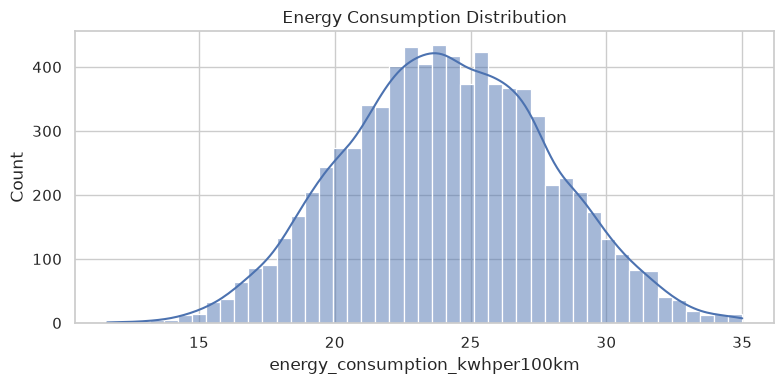

그래프 해석: 에너지 소비량은 약 24 kWh/100km 주변에 가장 많이 모여 있습니다.


In [80]:
# 타깃 분포를 확인한다.
plt.figure(figsize=(8, 4))
sns.histplot(data=ev_df, x=target, kde=True)
plt.title('Energy Consumption Distribution')
plt.tight_layout()
plt.show()
print('그래프 해석: 에너지 소비량은 약 24 kWh/100km 주변에 가장 많이 모여 있습니다.')

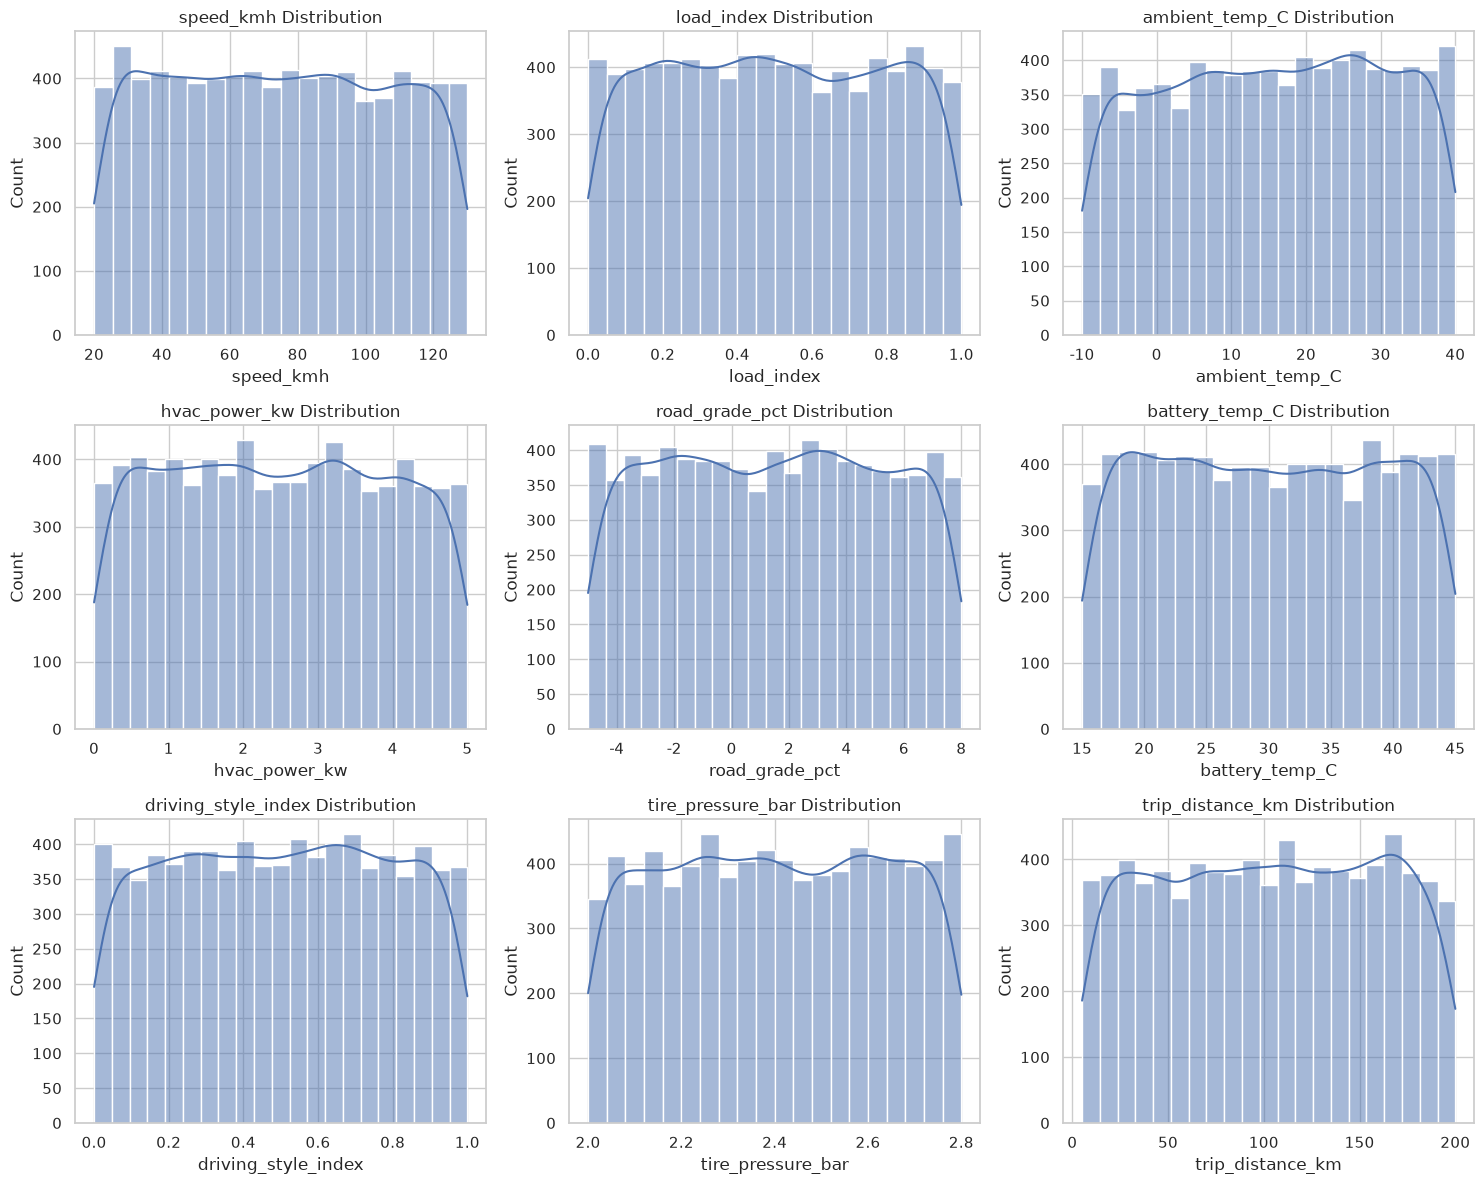

그래프 해석: 각 입력값은 특정 값에만 몰리지 않고 전체 범위에 비교적 고르게 분포합니다.


In [81]:
# Full Model과 Deployable Model의 피처를 구분한다.
full_feature_columns = [
    'speed_kmh', 'load_index', 'ambient_temp_C', 'hvac_power_kw',
    'road_grade_pct', 'battery_temp_C', 'driving_style_index',
    'tire_pressure_bar', 'trip_distance_km'
]

# 출발 전에 실제 서비스에서 확보 가능한 피처만 사용한다.
deployable_feature_columns = [
    'speed_kmh', 'load_index', 'ambient_temp_C',
    'hvac_power_kw', 'driving_style_index', 'trip_distance_km'
]

# EDA에서는 원본 CSV의 전체 피처를 확인한다.
feature_columns = full_feature_columns

figure, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(full_feature_columns):
    sns.histplot(data=ev_df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()
print('그래프 해석: 각 입력값은 특정 값에만 몰리지 않고 전체 범위에 비교적 고르게 분포합니다.')


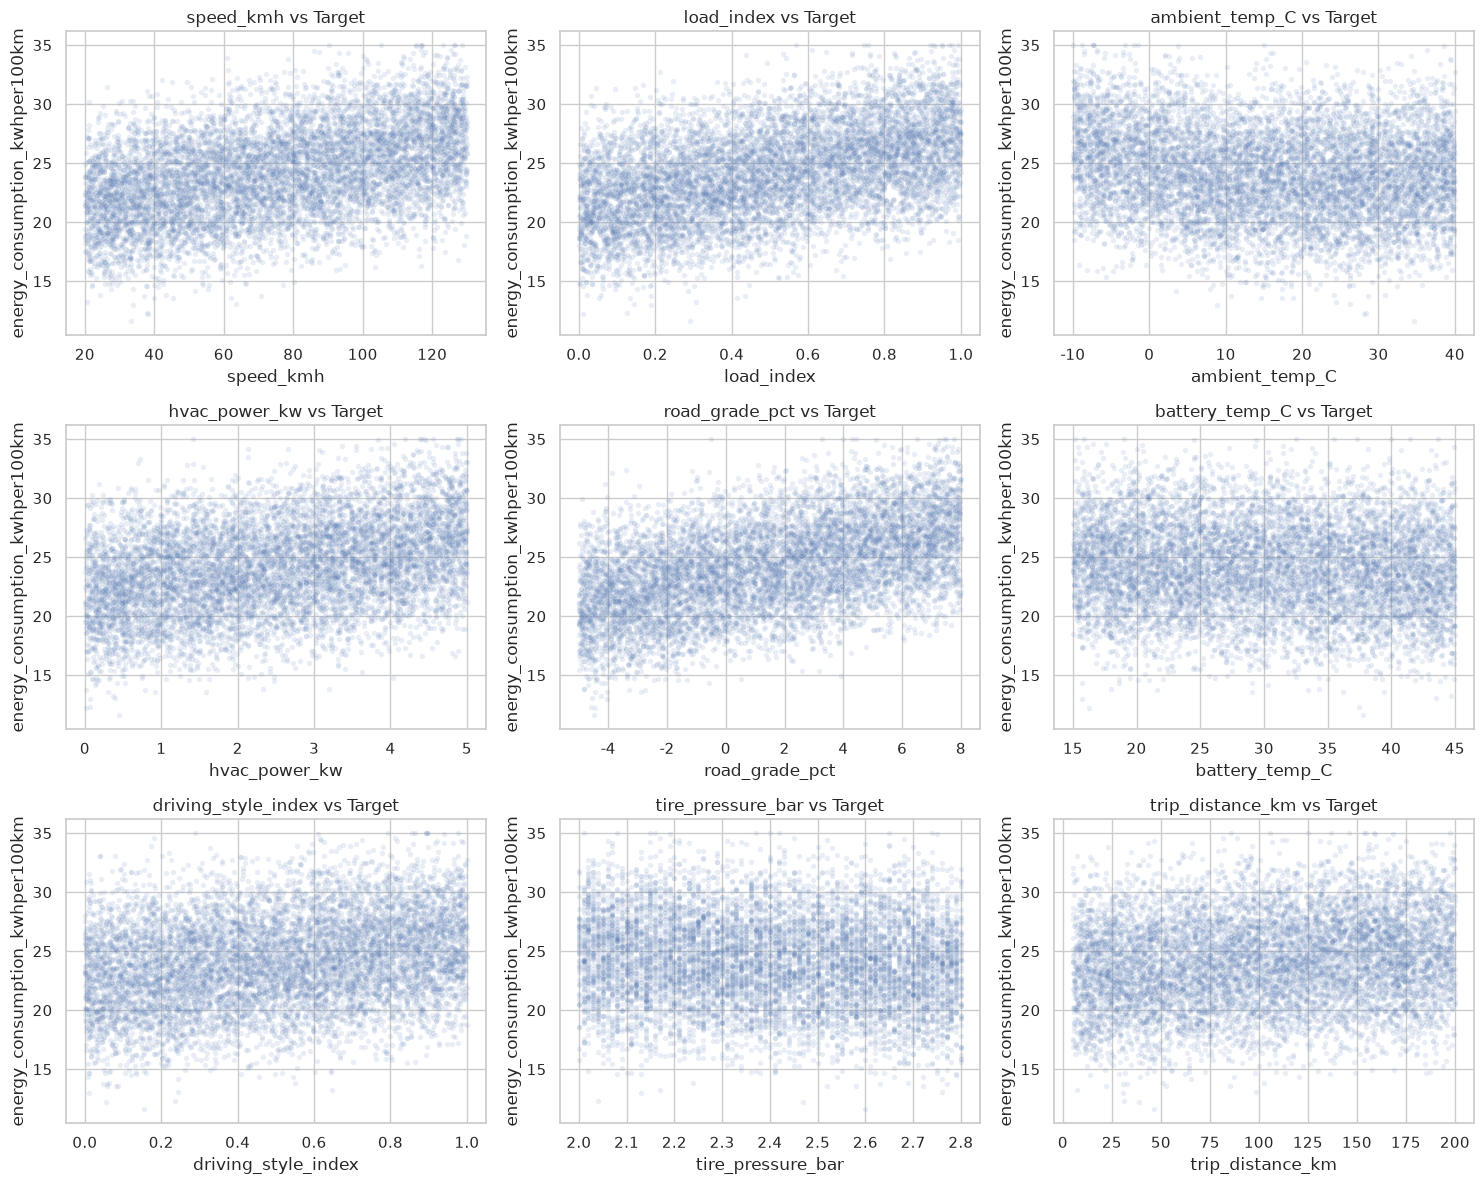

그래프 해석: 경사도, 적재 수준, 속도가 커질수록 에너지 소비량도 증가하는 모습입니다.


In [82]:
# 각 입력 피처와 타깃의 관계를 확인한다.
figure, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(feature_columns):
    sns.scatterplot(data=ev_df, x=col, y=target, alpha=0.12, s=15, ax=axes[i])
    axes[i].set_title(f'{col} vs Target')
plt.tight_layout()
plt.show()
print('그래프 해석: 경사도, 적재 수준, 속도가 커질수록 에너지 소비량도 증가하는 모습입니다.')

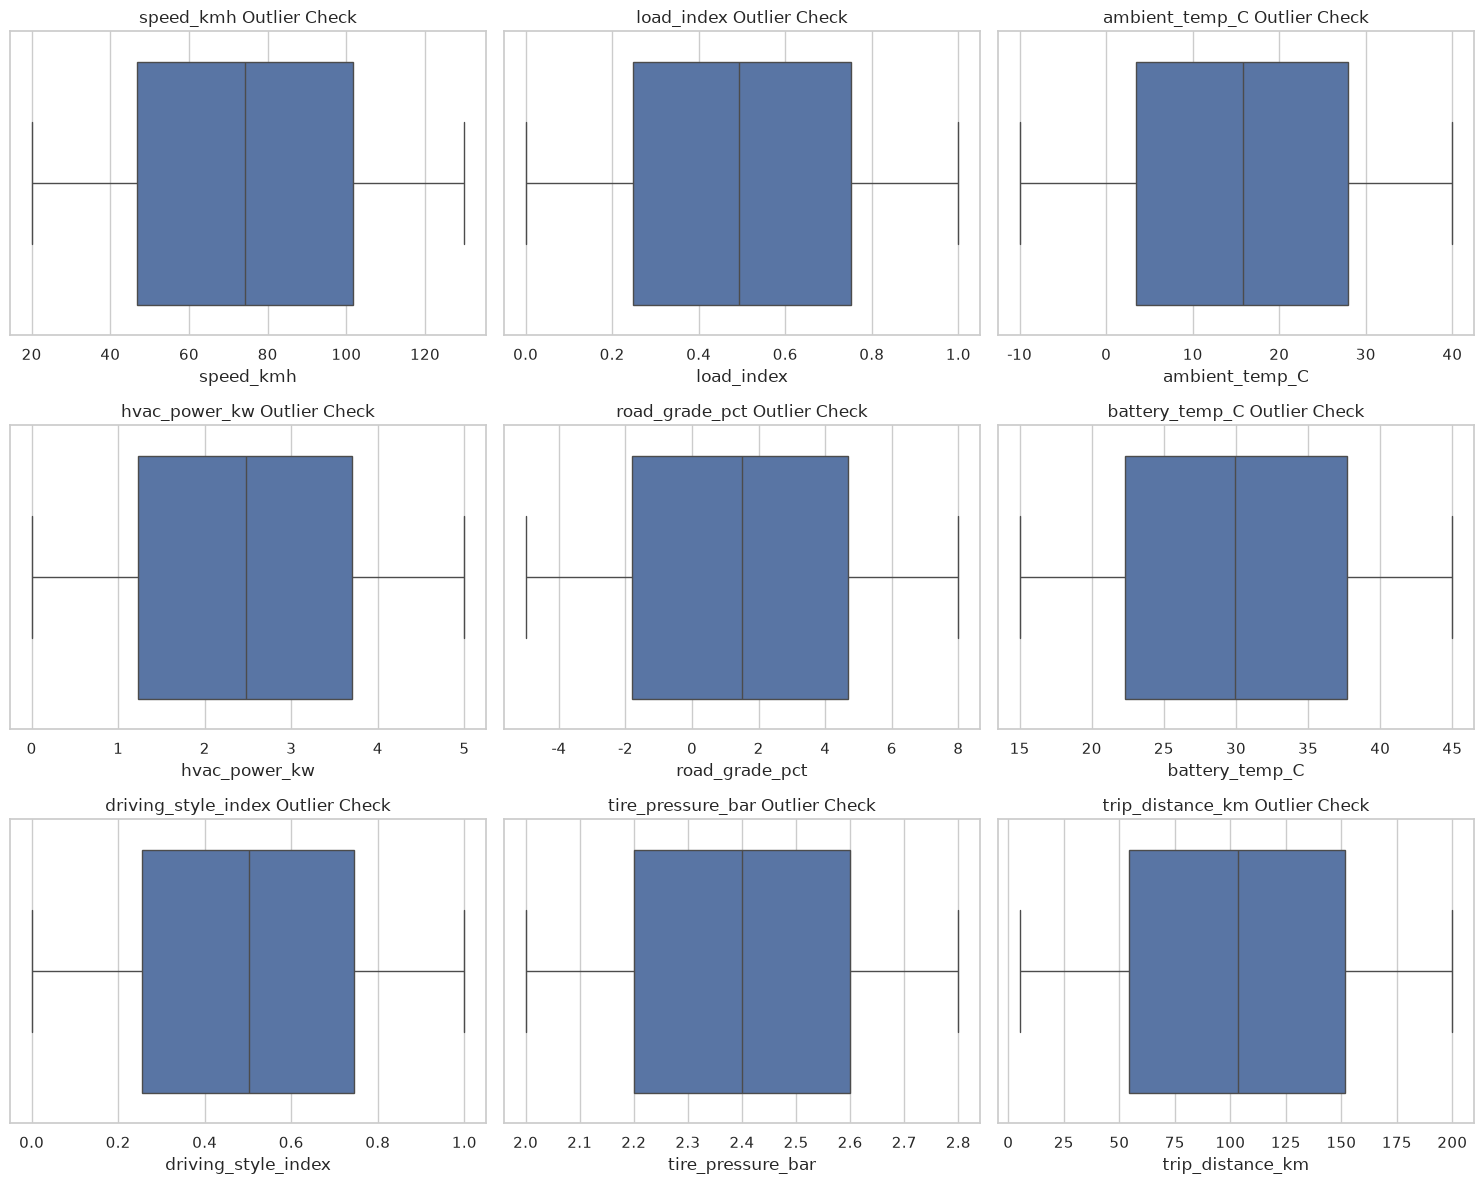

그래프 해석: 일부 값이 수염 밖에 보일 수 있으므로 데이터 범위를 함께 확인합니다.


In [83]:
# 입력 피처의 통계적 이상치를 확인한다.
figure, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(feature_columns):
    sns.boxplot(data=ev_df, x=col, ax=axes[i])
    axes[i].set_title(f'{col} Outlier Check')
plt.tight_layout()
plt.show()
print('그래프 해석: 일부 값이 수염 밖에 보일 수 있으므로 데이터 범위를 함께 확인합니다.')

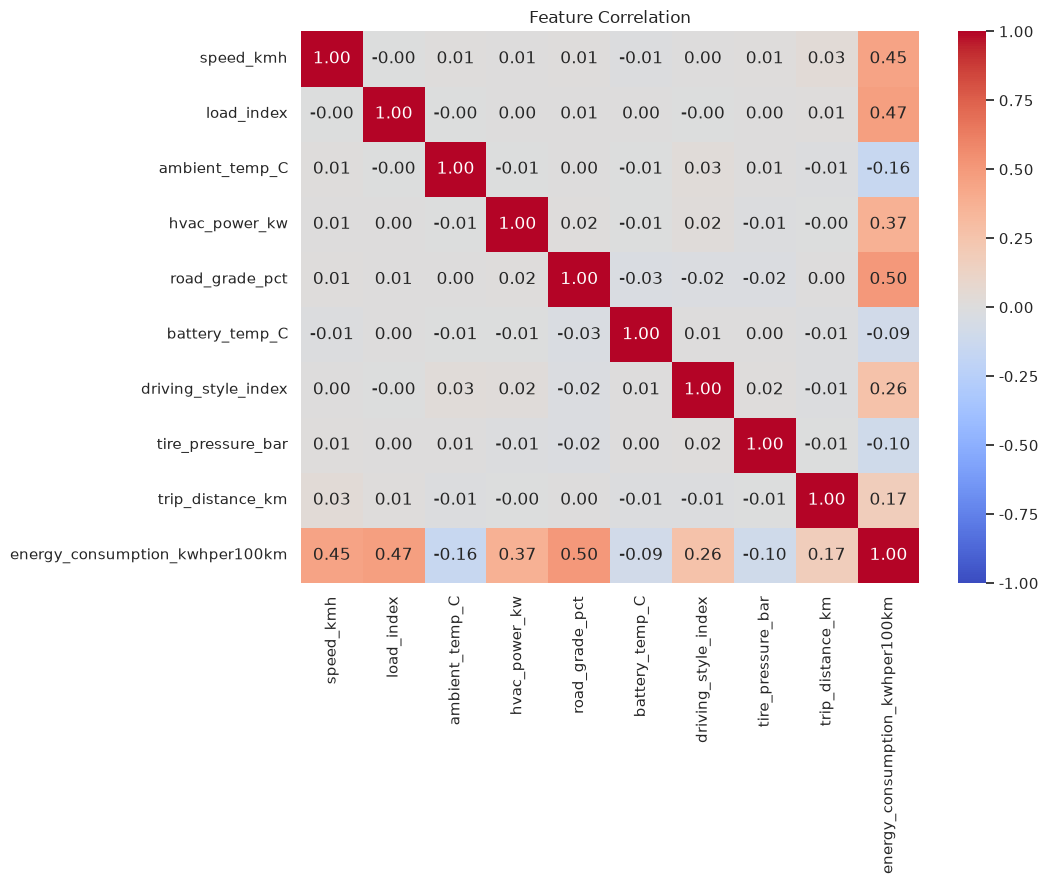

그래프 해석: 에너지 소비량은 경사도, 적재 수준, 속도와 비교적 강한 양의 상관관계를 보입니다.


In [84]:
# 전체 숫자형 변수의 상관관계를 대칭 색상 범위로 표현한다.
corr = ev_df[feature_columns + [target]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()
print('그래프 해석: 에너지 소비량은 경사도, 적재 수준, 속도와 비교적 강한 양의 상관관계를 보입니다.')

## 4. Train/Test 분할과 모델 평가

In [85]:
# 두 Feature Set이 완전히 같은 행으로 평가되도록 인덱스를 한 번만 분할한다.
y = ev_df[target]
train_index, test_index = train_test_split(
    ev_df.index, test_size=0.2, random_state=42
)
y_train = y.loc[train_index]
y_test = y.loc[test_index]

X_full_train = ev_df.loc[train_index, full_feature_columns]
X_full_test = ev_df.loc[test_index, full_feature_columns]
X_deploy_train = ev_df.loc[train_index, deployable_feature_columns]
X_deploy_test = ev_df.loc[test_index, deployable_feature_columns]

print('동일 Train/Test 행 사용:', len(train_index), len(test_index))
print('Full Model:', X_full_train.shape, X_full_test.shape)
print('Deployable Model:', X_deploy_train.shape, X_deploy_test.shape)


동일 Train/Test 행 사용: 6400 1600
Full Model: (6400, 9) (1600, 9)
Deployable Model: (6400, 6) (1600, 6)


In [86]:
# Linear Regression은 Feature Set별 학습 데이터로 각각 스케일링한다.
full_scaler = StandardScaler()
X_full_train_scaled = full_scaler.fit_transform(X_full_train)
X_full_test_scaled = full_scaler.transform(X_full_test)

deployable_scaler = StandardScaler()
X_deploy_train_scaled = deployable_scaler.fit_transform(X_deploy_train)
X_deploy_test_scaled = deployable_scaler.transform(X_deploy_test)


In [87]:
def evaluate_regression(y_true, y_pred):
    """회귀 모델을 R2, MAE, RMSE로 동일하게 평가한다."""
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

In [88]:
def train_three_models(feature_set_name, X_train, X_test,
                       X_train_scaled, X_test_scaled, y_train, y_test):
    """한 Feature Set에 동일한 세 모델을 학습하고 같은 지표로 평가한다."""
    models = {
        'Linear Regression': LinearRegression().fit(X_train_scaled, y_train),
        'Random Forest': RandomForestRegressor(
            n_estimators=200, random_state=42, n_jobs=-1
        ).fit(X_train, y_train),
        'XGBoost': XGBRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            random_state=42, n_jobs=-1
        ).fit(X_train, y_train)
    }

    predictions = {
        'Linear Regression': models['Linear Regression'].predict(X_test_scaled),
        'Random Forest': models['Random Forest'].predict(X_test),
        'XGBoost': models['XGBoost'].predict(X_test)
    }
    results = [
        {'Feature Set': feature_set_name, 'Model': name,
         **evaluate_regression(y_test, predictions[name])}
        for name in models
    ]
    return models, pd.DataFrame(results)


full_models, full_results = train_three_models(
    'Full', X_full_train, X_full_test,
    X_full_train_scaled, X_full_test_scaled, y_train, y_test
)
deployable_models, deployable_results = train_three_models(
    'Deployable', X_deploy_train, X_deploy_test,
    X_deploy_train_scaled, X_deploy_test_scaled, y_train, y_test
)

model_results = pd.concat([full_results, deployable_results], ignore_index=True)
model_results.sort_values(['Model', 'Feature Set'])


,Feature Set,Model,R2,MAE,RMSE
3,Deployable,Linear Regression,0.663777,1.775568,2.131622
0,Full,Linear Regression,0.924621,0.810735,1.009304
4,Deployable,Random Forest,0.657707,1.778584,2.150778
1,Full,Random Forest,0.900355,0.924615,1.160445
5,Deployable,XGBoost,0.669083,1.762220,2.114734
2,Full,XGBoost,0.938032,0.734065,0.915123


## 5. 9 Feature XGBoost 모델 학습 및 저장

9개 입력 컬럼으로 XGBoost 모델을 학습하고 평가한 뒤 저장한다.


In [89]:
# 모델을 만들고 학습 데이터를 넣어 학습한다.
best_model = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=42, n_jobs=-1
)
best_model.fit(X_full_train, y_train)

# 테스트 데이터의 예측값을 만든다.
best_pred = best_model.predict(X_full_test)
best_result = evaluate_regression(y_test, best_pred)
print('R2:', best_result['R2'])
print('MAE:', best_result['MAE'])
print('RMSE:', best_result['RMSE'])


R2: 0.9380321913609015
MAE: 0.734064967827797
RMSE: 0.9151230906898019


In [90]:
# 9 Feature XGBoost 하이퍼파라미터 튜닝

param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid_model = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_grid_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_full_train, y_train)

print('Best Params:', grid_search.best_params_)
print('Best CV R2:', grid_search.best_score_)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250, 'subsample': 0.8}
Best CV R2: 0.9421166492388637


In [91]:
# GridSearchCV 최적 모델의 Test 성능 평가

grid_best_model = grid_search.best_estimator_

grid_pred = grid_best_model.predict(X_full_test)

grid_result = evaluate_regression(y_test, grid_pred)

print('GridSearch Test R2:', grid_result['R2'])
print('GridSearch Test MAE:', grid_result['MAE'])
print('GridSearch Test RMSE:', grid_result['RMSE'])

GridSearch Test R2: 0.9438253046602678
GridSearch Test MAE: 0.6917053332233429
GridSearch Test RMSE: 0.8712981809908492


In [92]:
# GridSearchCV 최적 모델을 최종 서비스 모델로 사용
best_model = grid_best_model
best_result = grid_result

print('최종 모델: XGBoost + GridSearchCV')
print('Best Params:', grid_search.best_params_)
print('Final R2:', best_result['R2'])
print('Final MAE:', best_result['MAE'])
print('Final RMSE:', best_result['RMSE'])

최종 모델: XGBoost + GridSearchCV
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250, 'subsample': 0.8}
Final R2: 0.9438253046602678
Final MAE: 0.6917053332233429
Final RMSE: 0.8712981809908492


In [93]:
# 예측값을 비교할 기준 입력을 만든다.
reference_condition = X_full_train.median().to_frame().T
reference_condition['road_grade_pct'] = SIMULATED_ROAD_GRADE_PCT
reference_raw_prediction = float(best_model.predict(reference_condition[full_feature_columns])[0])

model_metadata = {
    'model_name': 'XGBoost 9 Feature + GridSearchCV',
    'model_type': 'XGBoost + GridSearchCV',
    'best_params': grid_search.best_params_,
    'best_cv_score': grid_search.best_score_,
    'feature_set': 'full_9_feature',
    'feature_names': full_feature_columns,
    'feature_columns': full_feature_columns,
    'feature_count': len(full_feature_columns),
    'simulated_road_grade_pct': SIMULATED_ROAD_GRADE_PCT,
    'feature_medians': X_full_train.median().to_dict(),
    'feature_min': X_full_train.min().to_dict(),
    'feature_max': X_full_train.max().to_dict(),
    'payload_max_kg_in_training_data': PAYLOAD_MAX_KG_IN_TRAINING_DATA,
    'reference_condition': reference_condition.iloc[0].to_dict(),
    'reference_raw_prediction': reference_raw_prediction,
    'test_metrics': best_result,
    'split': {'test_size': 0.2, 'random_state': 42}
}

joblib.dump(best_model, MODELS_DIR / 'truck_energy_model_9feature.pkl')
joblib.dump(model_metadata, MODELS_DIR / 'truck_energy_metadata_9feature.pkl')
joblib.dump(best_model, MODELS_DIR / 'truck_energy_model.pkl')
joblib.dump(model_metadata, MODELS_DIR / 'truck_energy_metadata.pkl')
print('9 Feature 모델 저장 완료:', MODELS_DIR / 'truck_energy_model_9feature.pkl')
print('서비스 피처:', model_metadata['feature_names'])

# 외부 API 없이 학습 데이터 중앙값으로 임의의 Segment 한 개를 테스트한다.
test_segment = X_full_train.median().to_frame().T
test_segment['road_grade_pct'] = model_metadata['simulated_road_grade_pct']
test_segment = test_segment[model_metadata['feature_names']]
if list(test_segment.columns) != model_metadata['feature_names']:
    raise ValueError('테스트 Segment의 Feature 순서가 학습 순서와 다릅니다.')
if test_segment.shape[1] != model_metadata['feature_count']:
    raise ValueError('테스트 Segment의 Feature 개수가 올바르지 않습니다.')
test_prediction = float(best_model.predict(test_segment)[0])
print('Model:', model_metadata['model_name'])
print('Feature Count:', model_metadata['feature_count'])
print('Feature Names:', model_metadata['feature_names'])
print('예측값:', test_prediction, 'kWh/100km')


9 Feature 모델 저장 완료: /home/aiuk/ml_ex/models/truck_energy_model_9feature.pkl
서비스 피처: ['speed_kmh', 'load_index', 'ambient_temp_C', 'hvac_power_kw', 'road_grade_pct', 'battery_temp_C', 'driving_style_index', 'tire_pressure_bar', 'trip_distance_km']
Model: XGBoost 9 Feature + GridSearchCV
Feature Count: 9
Feature Names: ['speed_kmh', 'load_index', 'ambient_temp_C', 'hvac_power_kw', 'road_grade_pct', 'battery_temp_C', 'driving_style_index', 'tire_pressure_bar', 'trip_distance_km']
예측값: 23.785364151000977 kWh/100km


# 외부 데이터 연결 구현 및 소량 테스트

이 절은 머신러닝, SOC 계산, 충전 최적화와 분리되어 있다. API 키는 `.env`에서만 읽으며 키 값은 출력하지 않는다.

- TMAP POI: `GET https://apis.openapi.sk.com/tmap/pois`
- TMAP 화물차 경로: `POST https://apis.openapi.sk.com/tmap/truck/routes`
- 환경공단 기본정보: `GET https://apis.data.go.kr/B552584/EvCharger/getChargerInfo`
- 환경공단 상태정보: `GET https://apis.data.go.kr/B552584/EvCharger/getChargerStatus`


In [94]:
# 외부 데이터 연결에 필요한 모듈과 상대경로를 준비한다.
import os
import json
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path
from urllib.parse import unquote

import geopandas as gpd
import pandas as pd
import requests
from dotenv import load_dotenv
from shapely.geometry import LineString

BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
ROAD_SHP_PATH = BASE_DIR / 'project_data' / '도로중심선.shp'
FIXED_LOCATIONS_PATH = PROCESSED_DIR / 'fixed_locations.json'
ROUTE_CACHE_PATH = PROCESSED_DIR / 'fixed_tmap_route.json'
ROUTE_CACHE_META_PATH = PROCESSED_DIR / 'fixed_tmap_route_request.json'

# 기존 환경변수를 덮어쓰지 않고 프로젝트 루트의 .env를 읽는다.
load_dotenv(BASE_DIR / '.env', override=False)
TMAP_APP_KEY = os.getenv('TMAP_APP_KEY')
DATA_GO_KR_SERVICE_KEY = os.getenv('DATA_GO_KR_SERVICE_KEY')

print('.env 파일 존재:', (BASE_DIR / '.env').exists())
print('TMAP_APP_KEY 설정:', bool(TMAP_APP_KEY))
print('DATA_GO_KR_SERVICE_KEY 설정:', bool(DATA_GO_KR_SERVICE_KEY))


.env 파일 존재: True
TMAP_APP_KEY 설정: True
DATA_GO_KR_SERVICE_KEY 설정: True


## 1. TMAP POI 검색

공식 POI 통합검색의 응답 좌표계를 `WGS84GEO`로 지정한다. 후보를 여러 개 보여준 뒤 사용자가 행 번호를 선택하도록 구성한다.


In [95]:
def search_tmap_poi(keyword, count=10):
    """TMAP에서 장소 후보를 검색하고 보기 쉬운 표로 반환한다."""
    if not TMAP_APP_KEY:
        raise RuntimeError('.env에 TMAP_APP_KEY가 설정되지 않았습니다.')

    url = 'https://apis.openapi.sk.com/tmap/pois'
    headers = {'appKey': TMAP_APP_KEY, 'Accept': 'application/json'}
    params = {
        'version': '1',
        'searchKeyword': keyword,
        'searchType': 'all',
        'searchtypCd': 'A',
        'reqCoordType': 'WGS84GEO',
        'resCoordType': 'WGS84GEO',
        'radius': '0',
        'page': 1,
        'count': count,
        'multiPoint': 'N',
        'poiGroupYn': 'N',
    }

    try:
        response = requests.get(url, headers=headers, params=params, timeout=30)
    except requests.RequestException as error:
        raise RuntimeError(f'TMAP POI 네트워크 연결 실패: {type(error).__name__}') from None
    print(f'{keyword} HTTP 상태:', response.status_code)
    if not response.ok:
        raise RuntimeError(f'TMAP POI 검색 실패: HTTP {response.status_code} / {response.text[:300]}')

    pois = response.json().get('searchPoiInfo', {}).get('pois', {}).get('poi', [])
    rows = []
    for poi in pois:
        lot_address = ' '.join(str(poi.get(name, '')).strip() for name in [
            'upperAddrName', 'middleAddrName', 'lowerAddrName',
            'detailAddrName', 'detailAddrname', 'firstNo', 'secondNo'
        ] if str(poi.get(name, '')).strip())
        road_address = ' '.join(str(poi.get(name, '')).strip() for name in [
            'upperAddrName', 'middleAddrName', 'roadName',
            'firstBuildNo', 'secondBuildNo'
        ] if str(poi.get(name, '')).strip())
        rows.append({
            '장소명': poi.get('name'),
            '주소': road_address or lot_address,
            '경도': pd.to_numeric(poi.get('frontLon') or poi.get('noorLon'), errors='coerce'),
            '위도': pd.to_numeric(poi.get('frontLat') or poi.get('noorLat'), errors='coerce'),
            'poi_id': poi.get('id'),
            'rpFlag': poi.get('rpFlag'),
        })

    result = pd.DataFrame(rows)
    if result.empty:
        raise RuntimeError(f'{keyword!r} 검색 결과가 없습니다.')
    return result


def test_tmap_poi_search():
    """두 장소를 검색한다. 실패하면 가짜 좌표 대신 오류를 출력한다."""
    results = {}
    for keyword in ['부산신항', '인천국제공항 화물터미널']:
        print(f'\n[{keyword} 상위 후보]')
        try:
            candidates = search_tmap_poi(keyword, count=10)
            display(candidates[['장소명', '주소', '경도', '위도']])
            results[keyword] = candidates
        except Exception as error:
            print('실패 원인:', error)
            results[keyword] = pd.DataFrame()
    return results


poi_results = test_tmap_poi_search()



[부산신항 상위 후보]


부산신항 HTTP 상태: 200


,장소명,주소,경도,위도
0,부산신항,부산 강서구 신항남로 330,128.834480,35.078161
1,부산신항만에이치디,서울 강남구 언주로 609 0,127.036906,37.509545
2,부산신항만에이치디 지하주차장,서울 강남구 언주로 609 0,127.036906,37.509545
3,부산신항만투자,서울 강남구 언주로 609 0,127.036906,37.509545
4,부산신항만투자 지하주차장,서울 강남구 언주로 609 0,127.036906,37.509545
5,부산신항국제터미널,부산 강서구 신항남로 330 0,128.834036,35.081438
6,부산신항만,부산 강서구 신항남로 330,128.833341,35.082938
7,부산신항만 동측게이트,부산 강서구 신항남로 330,128.833341,35.082938
8,부산신항만 서측게이트,부산 강서구 신항남로 330,128.796400,35.083021
9,부산신항8단지사랑으로부영아파트,경남 창원시 진해구 신항동로 136,128.812871,35.089076



[인천국제공항 화물터미널 상위 후보]
인천국제공항 화물터미널 HTTP 상태: 200


,장소명,주소,경도,위도
0,인천국제공항 화물터미널,인천 영종구,126.476014,37.466262
1,대한항공국제공항화물터미널,인천 영종구 공항로 271 0,126.467015,37.461707
2,인천국제공항 화물터미널 화물터미널 C동,인천 영종구 공항동로295번길 77 45,126.466626,37.470317
3,인천국제공항 화물터미널 화물터미널 B동,인천 영종구,126.462404,37.467929
4,인천국제공항 화물터미널 화물터미널 A동,인천 영종구 공항동로193번길 90 0,126.467209,37.463263
5,인천항공화물터미널B동,인천 영종구 공항동로295번길 77 65,126.463598,37.470178
6,DHL 인천공항 게이트웨이,인천 영종구 공항동로295번길 124 0,126.460682,37.470151
7,DHL 인천공항 게이트웨이 주차장,인천 영종구 공항동로295번길 124 0,126.460682,37.470151
8,FEDEX 인천공항사무소,인천 영종구 공항동로295번길 46 0,126.466070,37.473567
9,UPS 인천국제공항사무소,인천 영종구,126.466209,37.470234


## 2. TMAP 화물차 경로 테스트

아래 두 후보 번호와 차량 제원을 먼저 확인해 입력한다. 후보를 임의로 첫 번째 행으로 고르지 않는다. 화물차 API가 요구하는 폭·높이·적재중량·총중량·길이를 실제 운행 차량 기준으로 입력해야 호출된다.


In [96]:
# 사용자가 확정한 POI 후보 번호이다.
START_CANDIDATE_INDEX = 0
END_CANDIDATE_INDEX = 0

# 40t급 Volvo FH Electric 세미트레일러 운송 시뮬레이션 제원이다.
# Volvo FH Electric의 정확한 단일 실차 치수로 해석하지 않는다.
TRUCK_OPTIONS = {
    'truckType': '1',           # 화물자동차
    'truckWidth': 250,          # cm
    'truckHeight': 400,         # cm
    'truckWeight': 20000,       # kg, 프로젝트 가정 적재중량
    'truckTotalWeight': 40000,  # kg, 40t 조건
    'truckLength': 1670,        # cm
}


In [97]:
def _route_request_signature(start, end, truck_options):
    """동일 요청인지 확인할 때 사용할 키 없는 요청정보를 만든다."""
    return {
        'start_lon': float(start['경도']), 'start_lat': float(start['위도']),
        'end_lon': float(end['경도']), 'end_lat': float(end['위도']),
        'truck_options': {key: str(value) for key, value in truck_options.items()},
    }


def request_tmap_truck_route(start, end, truck_options, departure_time=None, use_cache=True):
    """TMAP 화물차 경로를 호출하고 성공 원문을 캐시에 저장한다."""
    if not TMAP_APP_KEY:
        raise RuntimeError('.env에 TMAP_APP_KEY가 설정되지 않았습니다.')

    missing = [key for key, value in truck_options.items() if value in (None, '')]
    if missing:
        raise ValueError(f'실제 차량 제원을 입력하세요: {missing}')

    signature = _route_request_signature(start, end, truck_options)
    if use_cache and ROUTE_CACHE_PATH.exists() and ROUTE_CACHE_META_PATH.exists():
        saved_signature = json.loads(ROUTE_CACHE_META_PATH.read_text(encoding='utf-8'))
        if saved_signature == signature:
            print('동일 경로 캐시 사용:', ROUTE_CACHE_PATH)
            return json.loads(ROUTE_CACHE_PATH.read_text(encoding='utf-8')), 200, True

    url = 'https://apis.openapi.sk.com/tmap/truck/routes'
    headers = {'appKey': TMAP_APP_KEY, 'Content-Type': 'application/json', 'Accept': 'application/json'}
    body = {
        'startX': str(start['경도']), 'startY': str(start['위도']),
        'endX': str(end['경도']), 'endY': str(end['위도']),
        'startName': str(start['장소명']), 'endName': str(end['장소명']),
        'reqCoordType': 'WGS84GEO', 'resCoordType': 'WGS84GEO',
        'searchOption': '0', 'trafficInfo': 'Y',
        'startTime': (departure_time or datetime.now()).strftime('%Y%m%d%H%M'),
        **{key: str(value) for key, value in truck_options.items()},
    }
    try:
        response = requests.post(
            url, params={'version': '1', 'format': 'json'},
            headers=headers, json=body, timeout=60
        )
    except requests.RequestException as error:
        raise RuntimeError(f'TMAP 화물차 경로 네트워크 연결 실패: {type(error).__name__}') from None
    print('TMAP 화물차 경로 HTTP 상태:', response.status_code)
    if not response.ok:
        raise RuntimeError(f'TMAP 화물차 경로 실패: HTTP {response.status_code} / {response.text[:500]}')

    route_json = response.json()
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    ROUTE_CACHE_PATH.write_text(json.dumps(route_json, ensure_ascii=False, indent=2), encoding='utf-8')
    ROUTE_CACHE_META_PATH.write_text(json.dumps(signature, ensure_ascii=False, indent=2), encoding='utf-8')
    return route_json, response.status_code, False




def load_or_create_fixed_tmap_route(force_refresh=False):
    """기본 실행에서는 저장된 고정 경로를 사용하고 API를 재호출하지 않는다."""
    if ROUTE_CACHE_PATH.exists() and not force_refresh:
        print('[TMAP] 저장된 고정 경로를 사용합니다.')
        print('[TMAP] API를 호출하지 않았습니다.')
        return json.loads(ROUTE_CACHE_PATH.read_text(encoding='utf-8')), True

    if not FIXED_LOCATIONS_PATH.exists():
        raise FileNotFoundError(f'확정 좌표 파일이 없습니다: {FIXED_LOCATIONS_PATH}')
    fixed = json.loads(FIXED_LOCATIONS_PATH.read_text(encoding='utf-8'))
    start = {
        '장소명': fixed['start']['name'],
        '위도': fixed['start']['lat'],
        '경도': fixed['start']['lon'],
    }
    end = {
        '장소명': fixed['end']['name'],
        '위도': fixed['end']['lat'],
        '경도': fixed['end']['lon'],
    }
    route_json, _, _ = request_tmap_truck_route(
        start, end, TRUCK_OPTIONS, use_cache=False
    )
    print('[TMAP] 새 화물차 경로를 조회했습니다.')
    print('[TMAP] fixed_tmap_route.json 저장 완료')
    return route_json, False

def summarize_tmap_route(route_json):
    """TMAP GeoJSON 응답에서 거리, 시간, 경로 좌표를 확인한다."""
    total_distance_m = None
    total_time_sec = None
    coordinates = []
    raw_coordinate_count = 0
    for feature in route_json.get('features', []):
        properties = feature.get('properties', {})
        geometry = feature.get('geometry', {})
        if total_distance_m is None and properties.get('totalDistance') is not None:
            total_distance_m = float(properties['totalDistance'])
        if total_time_sec is None and properties.get('totalTime') is not None:
            total_time_sec = float(properties['totalTime'])
        if geometry.get('type') == 'LineString':
            part = geometry.get('coordinates', [])
            raw_coordinate_count += len(part)
            if coordinates and part and coordinates[-1] == part[0]:
                part = part[1:]
            coordinates.extend(part)

    if total_distance_m is None or total_time_sec is None or len(coordinates) < 2:
        raise ValueError('TMAP 응답에서 총 거리, 총 시간 또는 경로 좌표를 찾지 못했습니다.')

    summary = {
        '총 거리(km)': total_distance_m / 1000,
        '예상 소요시간': pd.to_timedelta(total_time_sec, unit='s'),
        '경로 좌표 개수': raw_coordinate_count,
        '중복 연결점 제거 후 좌표 개수': len(coordinates),
    }
    return summary, LineString(coordinates)


def parse_tmap_route(route_json):
    """기존 Segment 코드와 연결할 수 있도록 경로선, km, 시간을 반환한다."""
    summary, route_line = summarize_tmap_route(route_json)
    return route_line, summary['총 거리(km)'], summary['예상 소요시간'].total_seconds() / 3600


In [98]:
def test_tmap_truck_route(force_refresh=False):
    """고정 경로를 생성하거나 저장된 원본 JSON을 불러와 요약한다."""
    route_json, from_cache = load_or_create_fixed_tmap_route(force_refresh=force_refresh)
    summary, route_line = summarize_tmap_route(route_json)
    for name, value in summary.items():
        print(f'{name}:', value)
    return route_json, route_line, summary, from_cache


# 저장된 경로가 있을 때만 파일을 읽는다. API는 호출하지 않는다.
if ROUTE_CACHE_PATH.exists():
    saved_route = json.loads(ROUTE_CACHE_PATH.read_text(encoding='utf-8'))
    saved_summary, saved_line = summarize_tmap_route(saved_route)
    tmap_route_test = (saved_route, saved_line, saved_summary, True)
else:
    tmap_route_test = None


## 3. 한국환경공단 전기자동차 충전소 API 테스트

현재 공공데이터포털 서비스의 XML 응답을 파싱한다. 기본정보와 상태정보는 `statId + chgerId`를 공통 키로 병합한다. 테스트 호출량은 각각 10~20건으로 제한한다.


In [99]:
def parse_items_xml(xml_text):
    """공공데이터포털 XML의 item들을 DataFrame으로 변환한다."""
    root = ET.fromstring(xml_text)
    result_code = root.findtext('.//resultCode')
    result_message = root.findtext('.//resultMsg')
    if result_code and result_code != '00':
        raise RuntimeError(f'공공데이터 API 오류 {result_code}: {result_message}')
    rows = [{child.tag: child.text for child in item} for item in root.findall('.//item')]
    return pd.DataFrame(rows)


def request_ev_charger_api(endpoint, page_no=1, num_rows=10, **filters):
    """환경공단 API를 소량 호출한다. 인증키는 출력하지 않는다."""
    if not DATA_GO_KR_SERVICE_KEY:
        raise RuntimeError('.env에 DATA_GO_KR_SERVICE_KEY가 설정되지 않았습니다.')
    if not 10 <= num_rows <= 20:
        raise ValueError('구조 확인 테스트는 num_rows를 10~20으로 지정하세요.')

    url = f'https://apis.data.go.kr/B552584/EvCharger/{endpoint}'
    # 환경변수에 URL 인코딩 키가 저장되어 있어도 requests가 한 번만 인코딩하도록 원문으로 바꾼다.
    service_key = unquote(DATA_GO_KR_SERVICE_KEY)
    params = {
        'serviceKey': service_key,
        'pageNo': page_no,
        'numOfRows': num_rows,
        'dataType': 'XML',
        **{key: value for key, value in filters.items() if value not in (None, '')},
    }
    try:
        response = requests.get(url, params=params, timeout=60)
    except requests.RequestException as error:
        # requests 예외에는 인증키가 포함된 요청 URL이 들어갈 수 있으므로 원문 예외를 출력하지 않는다.
        raise RuntimeError(f'{endpoint} 네트워크 연결 실패: {type(error).__name__}') from None
    print(f'{endpoint} HTTP 상태코드:', response.status_code)
    if not response.ok:
        raise RuntimeError(f'{endpoint} 호출 실패: HTTP {response.status_code}')
    try:
        return parse_items_xml(response.text)
    except ET.ParseError as error:
        raise RuntimeError(f'{endpoint} XML 파싱 실패: {error}; 응답 앞부분={response.text[:300]}') from error


def request_ev_charger_info(page_no=1, num_rows=10):
    """충전소·충전기 기본정보를 가져온다."""
    return request_ev_charger_api('getChargerInfo', page_no, num_rows)


def request_ev_charger_status(page_no=1, num_rows=10, period=10):
    """최근 상태가 갱신된 충전기의 상태정보를 가져온다."""
    return request_ev_charger_api('getChargerStatus', page_no, num_rows, period=period)


def request_keco_chargers(page_no=1, num_rows=10):
    """기존 프로젝트 함수명과 호환되는 기본정보 호출 함수이다."""
    return request_ev_charger_info(page_no, num_rows)


In [100]:
def print_charger_test_result(title, dataframe, related_names):
    """요청한 컬럼 목록과 앞 5행을 출력한다."""
    print(f'\n[{title}]')
    print('전체 응답 컬럼명:', dataframe.columns.tolist())
    display(dataframe.head(5))
    related = [name for name in related_names if name in dataframe.columns]
    print(f'{title} 관련 컬럼명:', related)


def test_ev_charger_apis(num_rows=10):
    """기본정보·상태정보를 각각 소량 호출하고 병합 가능한 표를 만든다."""
    info_df = pd.DataFrame()
    status_df = pd.DataFrame()

    try:
        info_df = request_ev_charger_info(num_rows=num_rows)
        print_charger_test_result('충전소 기본정보', info_df, ['output', 'powerType', 'method'])
    except Exception as error:
        print('충전소 기본정보 실패 원인:', error)

    try:
        status_df = request_ev_charger_status(num_rows=num_rows, period=10)
        print_charger_test_result('충전기 상태정보', status_df, ['stat', 'statUpdDt'])
    except Exception as error:
        print('충전기 상태정보 실패 원인:', error)

    merged_df = pd.DataFrame()
    merge_keys = ['statId', 'chgerId']
    if all(key in info_df.columns for key in merge_keys) and all(key in status_df.columns for key in merge_keys):
        merged_df = info_df.merge(
            status_df, on=merge_keys, how='left', suffixes=('_info', '_status')
        )
        print('병합 성공: statId + chgerId 기준')
        display(merged_df.head(5))
    else:
        print('병합 보류: 두 응답에서 statId와 chgerId를 모두 확인해야 합니다.')
    return info_df, status_df, merged_df


charger_info_test, charger_status_test, charger_merged_test = test_ev_charger_apis(num_rows=10)


getChargerInfo HTTP 상태코드: 200

[충전소 기본정보]
전체 응답 컬럼명: ['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail', 'location', 'lat', 'lng', 'useTime', 'busiId', 'bnm', 'busiNm', 'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt', 'powerType', 'output', 'method', 'zcode', 'zscode', 'kind', 'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn', 'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker']


,statNm,statId,chgerId,chgerType,addr,addrDetail,location,lat,lng,useTime,...,note,limitYn,limitDetail,delYn,delDetail,trafficYn,year,floorNum,floorType,maker
0,낙성대동주민센터,ME174013,01,06,서울특별시 관악구 낙성대로4가길 5,NaN,None,37.476296,126.9583876,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
1,서울추모공원,ME174027,01,06,서울특별시 서초구 양재대로12길 74,1층 입구,None,37.4536062,127.0428005,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
2,롯데마트 송파점,ME174029,01,06,서울특별시 송파구 중대로 80,지하4층 C8,None,37.4918392,127.1178931,24시간 이용가능,...,None,N,None,N,None,N,2017,4,B,시그넷
3,태화빌딩,ME174039,01,06,서울특별시 종로구 인사동5길 29,지상주차장,None,37.5718148,126.9850443,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
4,위미의례회관,ME174046,01,06,제주특별자치도 서귀포시 남원읍 중산간동로 6862,NaN,None,33.289615,126.6576261,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷


충전소 기본정보 관련 컬럼명: ['output', 'powerType', 'method']


getChargerStatus HTTP 상태코드: 200

[충전기 상태정보]
전체 응답 컬럼명: ['busiId', 'statId', 'chgerId', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt']


,busiId,statId,chgerId,stat,statUpdDt,lastTsdt,lastTedt,nowTsdt
0,ME,ME174013,01,2,20260828152401,20260828114815,20260828121903,None
1,ME,ME174027,01,2,20260828152407,20260828080418,20260828084740,None
2,ME,ME174029,01,2,20260828152405,20260828105413,20260828113004,None
3,ME,ME174039,01,2,20260828152418,20260828130133,20260828134741,None
4,ME,ME174046,01,2,20260828152341,20260827191800,20260827195320,None


충전기 상태정보 관련 컬럼명: ['stat', 'statUpdDt']
병합 성공: statId + chgerId 기준


,statNm,statId,chgerId,chgerType,addr,addrDetail,location,lat,lng,useTime,...,year,floorNum,floorType,maker,busiId_status,stat_status,statUpdDt_status,lastTsdt_status,lastTedt_status,nowTsdt_status
0,낙성대동주민센터,ME174013,01,06,서울특별시 관악구 낙성대로4가길 5,NaN,None,37.476296,126.9583876,24시간 이용가능,...,2017,1,F,시그넷,ME,2,20260828152401,20260828114815,20260828121903,None
1,서울추모공원,ME174027,01,06,서울특별시 서초구 양재대로12길 74,1층 입구,None,37.4536062,127.0428005,24시간 이용가능,...,2017,1,F,시그넷,ME,2,20260828152407,20260828080418,20260828084740,None
2,롯데마트 송파점,ME174029,01,06,서울특별시 송파구 중대로 80,지하4층 C8,None,37.4918392,127.1178931,24시간 이용가능,...,2017,4,B,시그넷,ME,2,20260828152405,20260828105413,20260828113004,None
3,태화빌딩,ME174039,01,06,서울특별시 종로구 인사동5길 29,지상주차장,None,37.5718148,126.9850443,24시간 이용가능,...,2017,1,F,시그넷,ME,2,20260828152418,20260828130133,20260828134741,None
4,위미의례회관,ME174046,01,06,제주특별자치도 서귀포시 남원읍 중산간동로 6862,NaN,None,33.289615,126.6576261,24시간 이용가능,...,2017,1,F,시그넷,ME,2,20260828152341,20260827191800,20260827195320,None


## 4. 도로 데이터 보관 상태

도로중심선·도로외곽선·종단선형 CSV는 향후 확장용으로 보관만 한다. 현재 MVP 실행에서는 파일을 읽거나 경사를 계산하지 않는다.


In [101]:
# 파일을 삭제하지 않았는지만 확인하고 데이터는 읽지 않는다.
archived_road_files = {
    '도로중심선 SHP': BASE_DIR / 'project_data' / '도로중심선.shp',
    '도로외곽선 SHP': BASE_DIR / 'project_data' / '도로외곽선.shp',
    '노선별 종단선형 CSV': BASE_DIR / 'project_data' / '한국도로공사_노선별 종단선형 현황.csv',
}
road_archive_ok = all(path.exists() for path in archived_road_files.values())
print('도로 관련 파일 보관 확인:', road_archive_ok)
print('MVP 경사 기능 사용:', False)


도로 관련 파일 보관 확인: False
MVP 경사 기능 사용: False


## 5. 외부 데이터 연결 체크리스트

체크 표시는 실제 응답과 실제 컬럼이 확인된 경우에만 `x`로 바뀐다.


In [102]:
def print_external_data_checklist():
    """외부 데이터 연결의 실제 성공 여부를 한눈에 출력한다."""
    start_ok = not poi_results.get('부산신항', pd.DataFrame()).empty
    end_ok = not poi_results.get('인천국제공항 화물터미널', pd.DataFrame()).empty
    route_ok = ROUTE_CACHE_PATH.exists()
    info_ok = not charger_info_test.empty
    power_ok = any(col in charger_info_test.columns for col in ['output', 'powerType'])
    status_ok = not charger_status_test.empty
    road_ok = road_archive_ok

    checks = [
        ('TMAP POI 검색 성공', start_ok and end_ok),
        ('부산신항 후보 좌표 확인', start_ok),
        ('인천공항 화물터미널 후보 좌표 확인', end_ok),
        ('TMAP 화물차 경로 호출 성공', route_ok),
        ('한국환경공단 충전소 기본정보 호출 성공', info_ok),
        ('충전용량/출력 컬럼 확인', power_ok),
        ('충전기 상태정보 호출 성공', status_ok),
        ('도로 파일 보관 확인 (MVP 미사용)', road_ok),
    ]
    for label, success in checks:
        print(f"[{'x' if success else ' '}] {label}")
    return dict(checks)


external_data_checks = print_external_data_checklist()


[x] TMAP POI 검색 성공
[x] 부산신항 후보 좌표 확인
[x] 인천공항 화물터미널 후보 좌표 확인
[x] TMAP 화물차 경로 호출 성공
[x] 한국환경공단 충전소 기본정보 호출 성공
[x] 충전용량/출력 컬럼 확인
[x] 충전기 상태정보 호출 성공
[ ] 도로 파일 보관 확인 (MVP 미사용)


# Phase 2. 실제 경로와 Segment별 에너지 예측

## 6. TMAP 화물차 경로 API

위 외부 데이터 연결 절의 `search_tmap_poi()`, `request_tmap_truck_route()`, `parse_tmap_route()`를 사용한다. 일반 자동차 `/tmap/routes`가 아니라 화물차 전용 `/tmap/truck/routes`를 호출한다.


## 7. 휴게소 후보와 최대 10km Segment

In [103]:
# 실제 휴게소 파일의 인코딩과 컬럼을 확인한다.
rest_df = pd.read_csv(required_files['전국휴게소'], encoding='cp949')
rest_aux_df = pd.read_csv(required_files['휴게소 편의시설'], encoding='cp949')
print(rest_df.columns.tolist())
rest_df.head()

['휴게소명', '도로종류', '도로노선번호', '도로노선명', '도로노선방향', '위도', '경도', '휴게소종류', '휴게소운영시작시각', '휴게소운영종료시각', '도로점용면적', '주차면수', '경정비가능여부', '주유소유무', 'LPG충전소유무', '전기차충전소유무', '버스환승가능여부', '쉼터유무', '화장실유무', '약국유무', '수유실유무', '매점유무', '음식점유무', '기타편의시설', '휴게소대표음식명', '휴게소전화번호', '데이터기준일자', '제공기관코드', '제공기관명']


,휴게소명,도로종류,도로노선번호,도로노선명,도로노선방향,위도,경도,휴게소종류,휴게소운영시작시각,휴게소운영종료시각,...,약국유무,수유실유무,매점유무,음식점유무,기타편의시설,휴게소대표음식명,휴게소전화번호,데이터기준일자,제공기관코드,제공기관명
0,밀양영남루(함양),고속국도,14,함양울산선,상행,35.489732,128.663321,일반휴게소,00:00,23:59,...,N,Y,Y,Y,NaN,비빔밥,055-355-7972,2026-01-26,B500004,한국도로공사
1,서부산(순천),고속국도,104,남해제2지선,하행,35.157197,128.948638,일반휴게소,00:00,23:59,...,N,Y,Y,Y,NaN,김치찌개,051-941-2110,2026-01-26,B500004,한국도로공사
2,남한강(통합),고속국도,451,중부내륙선,양방향,37.482835,127.466735,일반휴게소,00:00,23:59,...,N,Y,Y,Y,NaN,제육볶음,031-771-5991,2026-01-26,B500004,한국도로공사
3,횡성(인천),고속국도,50,영동선,상행,37.464983,128.135449,일반휴게소,00:00,23:59,...,N,Y,Y,Y,NaN,횡성더덕설렁탕,033-342-4200,2026-01-26,B500004,한국도로공사
4,횡성(강릉),고속국도,50,영동선,하행,37.462755,128.133969,일반휴게소,00:00,23:59,...,N,Y,Y,Y,NaN,횡성한우떡더덕스테이크,033-342-4231,2026-01-26,B500004,한국도로공사


In [104]:
def find_route_rest_areas(route_line_wgs84, max_distance_km=3.0):
    """경로에서 가까우며 EV 충전시설이 표시된 휴게소와 경로상 거리를 찾는다."""
    route_gdf = gpd.GeoDataFrame(geometry=[route_line_wgs84], crs='EPSG:4326').to_crs('EPSG:5179')
    route_line_m = route_gdf.geometry.iloc[0]

    valid = rest_df.dropna(subset=['위도', '경도']).copy()
    rest_gdf = gpd.GeoDataFrame(
        valid,
        geometry=gpd.points_from_xy(valid['경도'], valid['위도']),
        crs='EPSG:4326'
    ).to_crs('EPSG:5179')

    rest_gdf['distance_to_route_km'] = rest_gdf.geometry.distance(route_line_m) / 1000
    rest_gdf['route_position_km'] = rest_gdf.geometry.apply(route_line_m.project) / 1000
    candidates = rest_gdf[
        (rest_gdf['distance_to_route_km'] <= max_distance_km) &
        (rest_gdf['전기차충전소유무'].astype(str).str.upper() == 'Y')
    ].sort_values('route_position_km').copy()

    return candidates.to_crs('EPSG:4326')

In [105]:
def split_route_into_segments(route_line_wgs84, rest_positions_km=None, max_segment_km=10.0):
    """10km 경계와 휴게소 위치를 모두 분할점으로 사용한다."""
    route_gdf = gpd.GeoDataFrame(geometry=[route_line_wgs84], crs='EPSG:4326').to_crs('EPSG:5179')
    route_line_m = route_gdf.geometry.iloc[0]
    total_km = route_line_m.length / 1000

    split_km = list(np.arange(0, total_km, max_segment_km)) + [total_km]
    if rest_positions_km is not None:
        split_km += [float(x) for x in rest_positions_km if 0 < float(x) < total_km]
    split_km = sorted(set(round(x, 6) for x in split_km))

    segment_rows = []
    for segment_id, (start_km, end_km) in enumerate(zip(split_km[:-1], split_km[1:]), start=1):
        geometry_m = substring(route_line_m, start_km * 1000, end_km * 1000)
        geometry_wgs84 = gpd.GeoSeries([geometry_m], crs='EPSG:5179').to_crs('EPSG:4326').iloc[0]
        midpoint = geometry_wgs84.interpolate(0.5, normalized=True)
        segment_rows.append({
            'segment_id': segment_id, 'start_km': start_km, 'end_km': end_km,
            'segment_distance_km': end_km - start_km,
            'mid_lon': midpoint.x, 'mid_lat': midpoint.y,
            'geometry': geometry_wgs84
        })

    return gpd.GeoDataFrame(segment_rows, geometry='geometry', crs='EPSG:4326')

## 9. Open-Meteo 시간별 기온 연결

In [106]:
def get_open_meteo_temperature(latitude, longitude, pass_time):
    """Segment 통과시간과 가장 가까운 시간의 temperature_2m을 반환한다."""
    url = 'https://api.open-meteo.com/v1/forecast'
    params = {
        'latitude': latitude, 'longitude': longitude,
        'hourly': 'temperature_2m', 'timezone': 'Asia/Seoul',
        'forecast_days': 16
    }
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    hourly = response.json()['hourly']
    weather = pd.DataFrame({
        'time': pd.to_datetime(hourly['time']),
        'temperature_2m': hourly['temperature_2m']
    })
    nearest_index = (weather['time'] - pd.Timestamp(pass_time)).abs().idxmin()
    return float(weather.loc[nearest_index, 'temperature_2m'])

[Open-Meteo 공식 문서](https://open-meteo.com/en/docs)는 `/v1/forecast`의 시간별 `temperature_2m`을 제공한다. 예보 범위를 벗어난 출발시간에는 호출 결과를 임의 보간하지 않고 오류로 처리해야 한다.

## 10. Segment ML 입력과 Volvo 소비량 보정

In [107]:
def prepare_segment_features(segments_df, total_route_hours, departure_time,
                             load_percent, hvac_power_kw, battery_temp_C,
                             driving_style_index, tire_pressure_bar,
                             metadata):
    """서비스 입력과 고정 시뮬레이션 경사 조건으로 Segment 값을 만든다."""
    result = segments_df.copy()
    total_distance = result['segment_distance_km'].sum()

    # TMAP Segment 시간이 없을 때만 총 예상시간을 거리 비율로 배분하는 대체 방법이다.
    result['duration_hour'] = total_route_hours * result['segment_distance_km'] / total_distance
    result['speed_kmh'] = result['segment_distance_km'] / result['duration_hour']
    result['arrival_hour'] = result['duration_hour'].cumsum()
    result['pass_time'] = result['arrival_hour'].apply(
        lambda h: departure_time + timedelta(hours=h)
    )

    result['ambient_temp_C'] = result.apply(
        lambda row: get_open_meteo_temperature(
            row['mid_lat'], row['mid_lon'], row['pass_time']
        ), axis=1
    )
    result['load_index'] = load_percent / 100
    result['hvac_power_kw'] = hvac_power_kw
    result['battery_temp_C'] = battery_temp_C
    result['driving_style_index'] = driving_style_index
    result['tire_pressure_bar'] = tire_pressure_bar
    result['trip_distance_km'] = result['segment_distance_km']
    # 모든 구간에 같은 입력값을 넣는다.
    result['road_grade_pct'] = metadata['simulated_road_grade_pct']

    # 누락 없이 학습 당시 9개 피처가 모두 있는지 확인한다.
    features = metadata['feature_names']
    if len(features) != metadata['feature_count']:
        raise ValueError('메타데이터의 Feature 개수와 이름 목록이 다릅니다.')
    missing = [col for col in features if col not in result.columns]
    if missing:
        raise ValueError(f'Segment 입력에 필요한 컬럼이 없습니다: {missing}')
    return result


In [108]:
def predict_segment_energy(segments_df, model, metadata):
    """ML 변화율을 Volvo 기준 소비량에 적용해 Segment별 소비전력을 계산한다."""
    result = segments_df.copy()
    features = metadata['feature_names']
    if len(features) != metadata['feature_count']:
        raise ValueError('메타데이터의 Feature 개수와 이름 목록이 다릅니다.')
    missing = [col for col in features if col not in result.columns]
    if missing:
        raise ValueError(f'예측에 필요한 Segment Feature가 없습니다: {missing}')
    prediction_input = result.loc[:, features]
    if list(prediction_input.columns) != features:
        raise ValueError('Segment Feature 순서가 모델 학습 순서와 다릅니다.')
    result['segment_raw_prediction'] = model.predict(prediction_input)
    result['correction_factor'] = (
        result['segment_raw_prediction'] / metadata['reference_raw_prediction']
    )
    result['truck_kwh_per_100km'] = VOLVO_REFERENCE_KWH_100KM * result['correction_factor']
    result['segment_energy_kwh'] = (
        result['truck_kwh_per_100km'] * result['segment_distance_km'] / 100
    )
    return result

# Phase 3. SOC와 충전 계획

## 11. Segment별 SOC 계산

In [109]:
def simulate_soc(segments_df, start_soc):
    """출발 SOC에서 Segment 소비전력을 순서대로 차감한다."""
    result = segments_df.copy()
    current_energy_kwh = VOLVO_USABLE_BATTERY_KWH * start_soc / 100
    soc_values = []

    for energy in result['segment_energy_kwh']:
        current_energy_kwh -= energy
        soc_values.append(current_energy_kwh / VOLVO_USABLE_BATTERY_KWH * 100)

    result['arrival_soc'] = soc_values
    return result

## 12. 휴게소 편의시설과 충전소 데이터

In [110]:
# 휴게소 보조정보를 이름 기준으로 연결하되 실제 컬럼을 먼저 확인한다.
print(rest_aux_df.columns.tolist())
rest_enriched = rest_df.merge(rest_aux_df, on='휴게소명', how='left', suffixes=('', '_aux'))
rest_enriched.head()

['휴게소명', '전화번호', '편의시설', '브랜드매장', '경정비소', 'ex-화물차라운지', '세차장']


,휴게소명,도로종류,도로노선번호,도로노선명,도로노선방향,위도,경도,휴게소종류,휴게소운영시작시각,휴게소운영종료시각,...,휴게소전화번호,데이터기준일자,제공기관코드,제공기관명,전화번호,편의시설,브랜드매장,경정비소,ex-화물차라운지,세차장
0,밀양영남루(함양),고속국도,14,함양울산선,상행,35.489732,128.663321,일반휴게소,00:00,23:59,...,055-355-7972,2026-01-26,B500004,한국도로공사,NaN,NaN,NaN,NaN,NaN,NaN
1,서부산(순천),고속국도,104,남해제2지선,하행,35.157197,128.948638,일반휴게소,00:00,23:59,...,051-941-2110,2026-01-26,B500004,한국도로공사,NaN,NaN,NaN,NaN,NaN,NaN
2,남한강(통합),고속국도,451,중부내륙선,양방향,37.482835,127.466735,일반휴게소,00:00,23:59,...,031-771-5991,2026-01-26,B500004,한국도로공사,NaN,NaN,NaN,NaN,NaN,NaN
3,횡성(인천),고속국도,50,영동선,상행,37.464983,128.135449,일반휴게소,00:00,23:59,...,033-342-4200,2026-01-26,B500004,한국도로공사,NaN,NaN,NaN,NaN,NaN,NaN
4,횡성(강릉),고속국도,50,영동선,하행,37.462755,128.133969,일반휴게소,00:00,23:59,...,033-342-4231,2026-01-26,B500004,한국도로공사,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
# 한전 CSV는 정적 위치·운영정보 확인용이며 충전 출력이 없으므로 충전시간 계산에는 사용하지 않는다.
kepco_charger_df = pd.read_csv(required_files['한전 충전소 보조자료'], encoding='cp949')
print(kepco_charger_df.columns.tolist())
kepco_charger_df.head()

['충전소아이디', '충전소명', '충전소주소', '상세주소', '위도', '경도', '이용가능시간', '연락처', '등록일자']


,충전소아이디,충전소명,충전소주소,상세주소,위도,경도,이용가능시간,연락처,등록일자
0,44,원주지사(공용),강원특별자치도 원주시 우산동 316-9,지사주차장,37.372274,127.938467,06:00~23:00,1899-2100,2016/10/27
1,18,국회의사당,서울특별시 영등포구 여의도동 1,국회의사당 본관후문 1층 주차장,37.532697,126.914212,주중/주말 : 24시간,1899-2100,2016/10/27
2,41,제물포지사,인천광역시 미추홀구 도화동 999,지상주차장 끝쪽,37.469358,126.660267,24시간 개방,1899-2100,2016/10/27
3,137,제주직할,제주특별자치도 제주시 연동 322-2,본관건물 왼쪽,33.489037,126.501302,24시간,1899-2100,2016/10/27
4,42,강릉특별지사,강원특별자치도 강릉시 포남동 1255,지사주차장,37.782175,128.918810,주중/주말 : 06:00~23:00,1899-2100,2016/10/27


환경공단 기본정보·상태정보 호출과 XML 파싱은 위 외부 데이터 연결 절의 함수들을 그대로 사용한다.


In [112]:
def extract_verified_charger_power(chargers_df):
    """응답에 실제 출력 컬럼이 있을 때만 숫자로 변환한다."""
    possible_columns = [c for c in ['output', 'power', '충전용량', '충전출력'] if c in chargers_df.columns]
    if not possible_columns:
        print('충전 출력 컬럼이 없습니다.')
        return chargers_df.assign(charger_kw=np.nan)
    result = chargers_df.copy()
    result['charger_kw'] = pd.to_numeric(result[possible_columns[0]], errors='coerce')
    return result

## 13. 충전시간과 계획 비교

In [113]:
def estimate_charging_time(current_soc, target_soc, charger_kw):
    """충전량을 충전 출력으로 나누어 충전시간을 계산한다."""
    if pd.isna(charger_kw) or charger_kw <= 0:
        return np.nan
    effective_kw = min(float(charger_kw), VOLVO_MAX_CHARGING_KW)
    charge_kwh = VOLVO_USABLE_BATTERY_KWH * (target_soc - current_soc) / 100
    return max(charge_kwh, 0) / effective_kw

In [114]:
def evaluate_charging_plan(route_energy_kwh, route_drive_hours, stops_df,
                           selected_indices, start_soc, safety_soc):
    """선택한 충전 정차 조합의 안전성·횟수·충전시간을 평가한다."""
    selected = stops_df.iloc[list(selected_indices)].sort_values('route_position_km')
    selected_positions = selected['route_position_km'].tolist()
    total_distance = route_energy_kwh['end_km'].max()
    checkpoints = selected_positions + [total_distance]

    current_energy = VOLVO_USABLE_BATTERY_KWH * start_soc / 100
    previous_km = 0.0
    total_charge_hours = 0.0
    stop_details = []

    for checkpoint_index, checkpoint_km in enumerate(checkpoints):
        mask = ((route_energy_kwh['end_km'] > previous_km) &
                (route_energy_kwh['end_km'] <= checkpoint_km + 1e-6))
        current_energy -= route_energy_kwh.loc[mask, 'segment_energy_kwh'].sum()
        arrival_soc = current_energy / VOLVO_USABLE_BATTERY_KWH * 100
        if arrival_soc < safety_soc:
            return {'feasible': False}

        if checkpoint_index < len(selected):
            stop = selected.iloc[checkpoint_index]
            next_km = checkpoints[checkpoint_index + 1]
            next_mask = ((route_energy_kwh['end_km'] > checkpoint_km) &
                         (route_energy_kwh['end_km'] <= next_km + 1e-6))
            needed_energy = route_energy_kwh.loc[next_mask, 'segment_energy_kwh'].sum()
            target_energy = needed_energy + VOLVO_USABLE_BATTERY_KWH * safety_soc / 100
            charge_kwh = max(0, target_energy - current_energy)
            target_soc = (current_energy + charge_kwh) / VOLVO_USABLE_BATTERY_KWH * 100
            if target_soc > 100 or pd.isna(stop['charger_kw']):
                return {'feasible': False}
            charge_hours = estimate_charging_time(arrival_soc, target_soc, stop['charger_kw'])
            current_energy += charge_kwh
            total_charge_hours += charge_hours
            stop_details.append({
                '휴게소명': stop['휴게소명'], '도착_SOC': arrival_soc,
                '충전후_SOC': target_soc, '충전기_kW': stop['charger_kw'],
                '충전량_kWh': charge_kwh, '충전시간_hour': charge_hours,
                '화물차_접근성': stop.get('truck_access', 'Unknown')
            })
        previous_km = checkpoint_km

    return {
        'feasible': True, 'charge_count': len(selected),
        'charge_hours': total_charge_hours,
        'drive_hours': route_drive_hours,
        'total_hours': route_drive_hours + total_charge_hours,
        'destination_soc': current_energy / VOLVO_USABLE_BATTERY_KWH * 100,
        'stops': stop_details
    }

In [115]:
def find_best_charging_plan(route_energy_kwh, route_drive_hours, stops_df,
                            start_soc, safety_soc):
    """안전 SOC → 최소 정차 → 최소 총시간 우선순위로 모든 정차 조합을 비교한다."""
    feasible_plans = []
    stop_count = len(stops_df)
    for count in range(stop_count + 1):
        for selected_indices in itertools.combinations(range(stop_count), count):
            plan = evaluate_charging_plan(
                route_energy_kwh, route_drive_hours, stops_df,
                selected_indices, start_soc, safety_soc
            )
            if plan.get('feasible'):
                feasible_plans.append(plan)
        if feasible_plans:
            break

    if not feasible_plans:
        return None
    return min(feasible_plans, key=lambda p: (p['charge_count'], p['total_hours']))

# Phase 4. 통합 실행과 Streamlit 준비

## 14. 사용자 입력과 통합 실행 전 차단조건

In [116]:
# 실제 서비스에서는 Streamlit 입력값으로 교체한다.
user_input = {
    'start_soc': 80.0,
    'departure_time': datetime.now().replace(minute=0, second=0, microsecond=0),
    'load_percent': 70.0,
    'hvac_power_kw': 2.0,
    'driving_style_index': 0.5,
    'safety_soc': 15.0
}
user_input

{'start_soc': 80.0,
 'departure_time': datetime.datetime(2026, 8, 28, 15, 0),
 'load_percent': 70.0,
 'hvac_power_kw': 2.0,
 'driving_style_index': 0.5,
 'safety_soc': 15.0}

In [117]:
# 도로 경사는 MVP 차단조건이 아니다. 외부 API 연결만 확인한다.
integration_blockers = []
if not TMAP_APP_KEY:
    integration_blockers.append('TMAP_APP_KEY 미설정')
if not DATA_GO_KR_SERVICE_KEY:
    integration_blockers.append('DATA_GO_KR_SERVICE_KEY 미설정')

if integration_blockers:
    print('통합 실행 BLOCKED')
    for blocker in integration_blockers:
        print('-', blocker)
else:
    print('MVP 통합 실행 준비 완료: 고정 시뮬레이션 경사 조건 사용')


MVP 통합 실행 준비 완료: 고정 시뮬레이션 경사 조건 사용


## 15. 실제 MVP 통합 실행 순서

1. TMAP POI 검색으로 부산신항·인천공항 화물터미널 좌표를 확인한다.
2. TMAP 화물차 경로를 받고 최대 10km 및 휴게소 위치에서 Segment를 나눈다.
3. TMAP 예상속도, Open-Meteo 예보 기온, 사용자 적재·HVAC·운전 스타일을 준비한다.
4. Full 9 Feature ML 모델로 Segment별 소비량을 예측하고 Volvo 기준으로 상대 보정한다.
5. Segment별 소비전력과 SOC를 계산한다.
6. 경로상 휴게소와 실제 충전기 정보를 연결한다.
7. 충전시간을 계산하고 최소 정차·최소 총 소요시간 계획을 추천한다.


## 16. 최종 출력 형식

In [118]:
def print_final_plan(route_distance_km, route_drive_hours, start_soc,
                     total_energy_kwh, departure_time, best_plan):
    """서비스와 보고서에서 사용할 최종 결과를 일정한 형식으로 출력한다."""
    if best_plan is None:
        print('안전 SOC를 만족하는 충전 계획을 찾지 못했습니다.')
        return

    print(f'총 경로 거리: {route_distance_km:.1f} km')
    print(f'예상 주행시간: {route_drive_hours:.2f} hour')
    print(f'출발 SOC: {start_soc:.1f}%')
    print(f'예상 총 소비전력: {total_energy_kwh:.1f} kWh')
    print(f'총 충전 횟수: {best_plan["charge_count"]}')
    print(f'총 충전시간: {best_plan["charge_hours"]:.2f} hour')
    print(f'예상 도착시간: {departure_time + timedelta(hours=best_plan["total_hours"])}')
    print(f'목적지 도착 SOC: {best_plan["destination_soc"]:.1f}%')
    print(pd.DataFrame(best_plan['stops']))

## 17. Streamlit 화면 설계

- 입력: 출발 SOC, 출발시간, 적재 수준(%), HVAC, 운전 스타일, 안전 SOC
- 자동 연결: TMAP 예상속도, Open-Meteo 예보 기온, Segment 거리
- 지도: 부산신항, TMAP 화물차 경로, 추천 충전 휴게소, 인천공항 화물터미널
- 출력: 총 거리·주행시간·소비전력·추천 휴게소·충전 전후 SOC·충전 출력·충전량·충전시간·도착 SOC
